***
# Homework 6: numpy and matplotlib

**Course:** STAT 606 - Computing in Data Science and Statistics SP24

**Name:** Shrivats Sudhir

**NetID:** ssudhir2

**Email:** ssudhir2@wisc.edu

**Collaborators:** Samuel Merten.

**Date:** March 8th, 2024
***

In [14]:
import numpy as np
import scipy as scp
import matplotlib.pyplot as plt

## 1.) Warmup: Around the Semicircular Law (3 points, spent $\approx$ 40 minutes)

**The (comparatively) young field of random matrix theory (RMT) concerns the behavior of certain matrices with independent random entries. A landmark result in RMT concerns the behavior of the eigenvalues of a random symmetric matrix with normal entries. Under the proper scaling, the joint distribution of the eigenvalues of such a matrix follows the *Wigner semicircular distribution*, which has density**

$$ f(x) = 
\begin{cases} 
\frac{\sqrt{4 - x^2}}{2\pi} & \text{If}\;-2 \le x \le 2\\
0 & \text{Otherwise}
\end{cases} \quad \quad (1)$$

**That is, a symmetric matrix with random normal entries will have eigenvalues whose histogram looks more and more like a semicircle of radius $2$ as n increases to $\infty$. In particular, define a matrix-valued random variable $Z \in \mathbb{R}^{n \times n}$ by generating $Z_{ij}$ iid normal with mean $0$ and variance $\frac{1}{n}$ for all $1 \le i \le j \le n$, and set $Z_{ji} = Z_{ij}$ for $1 \le j \le i \le n$. Then the matrix $Z \in \mathbb{R}^{n \times n}$ is called a *Wigner matrix*.**

**Define a function `wigner_density` that takes a single number (integer or float) as its input and returns a float as its output, given by the value of the semicircular density evaluated at the input. That is, for a number $x$, `wigner_density(x)` should return $f(x)$, where $f$ is defined above in Equation (1). You do not need to perform any error checking in this function, but note that your function should operate equally well on Python ints/floats and on numpy ints/floats, and you should be able to accomplish this without checking the type of the input. Use the `numpy.sqrt` function for the square root, NOT the Python `math.sqrt` function.**

In [15]:
def wigner_density(x):
    if -2 <= x and x <= 2:
        return np.sqrt(4 - x**2) / (2 * (np.pi))
    else:
        return 0

**Define a function `generate_wigner` that takes a single positive integer `n` as its argument and returns a random $n$-by-$n$ Wigner matrix. Your function should raise an appropriate error in the event that the input is not a positive integer. The output of your function may be either a `numpy` matrix or simply a `numpy` array, though I would recommend the former, for ease of use in the next sub-problem. You can cast a 2-dimensional `numpy` array a to a matrix by writing `np.matrix(a)`.** 

**Hint: depending on the solution you choose, you may find the `numpy.triu` and `numpy.tril` functions to be useful. A different solution makes use of the `scipy.spatial.distance.squareform` function.**

In [16]:
def generate_wigner(n):

    if not isinstance(n, (int, )):
        raise TypeError(f'n = {n} must be of type int.') # raises error when n is not of type int.
    if n <= 0:
        raise ValueError(f'n = {n} must be a positive integer.') # raises error when n is not a positive integer.
    
    Z = np.zeros((n, n)) # np.zeros((n, n)) gives us a (n-by-n) 2-dimensional numpy array of zeros.
    
    for i in range(n):
        for j in range(i, n):
            sample = np.random.default_rng().normal(loc = 0, scale = 1/n, size = 1) # get a single sample from a normal distribution
            Z[i, j] = sample[0]
            Z[j, i] = sample[0]
            
    return Z

**The RMT result referenced above states that the joint distribution of the eigenvalues of a random Wigner matrix converges to the semicircular law. Write a function `get_spectrum` that takes a numpy matrix or 2-dimensional numpy array and returns a numpy array of its eigenvalues in *non-decreasing* order. You do not need to perform any error checking for this function.**

In [17]:
def get_spectrum(Z):
    return np.sort(np.linalg.eigh(Z)[0])

def scale_wigner_eigenvalue(List, upper, lower):
    scaled_list = []
    for x in List:
        scaled_x = (x - min(List)) / (max(List) - min(List)) * (upper - lower) + lower
        scaled_list.append(scaled_x)
    return scaled_list

**Create a plot with four subplots, arranged vertically, each showing a (normalized) histogram, in blue, of the eigenvalues of a random $n$-by-$n$ Wigner matrix for $n = 100, 200, 500$ and $1000$. In each subplot, overlay a red curve indicating the density of the semicircular law, as defined in (1). Save this plot in a `.png` file called `wigner_plots.png` and include it in your submission.**

**Hint: depending on how you implemented wigner_density above, you may find the numpy.vectorize function helpful.**

In [18]:
def wigner_plot(arr, scaled_wigner_eigenvalue, x ,y):

    fig, axs = plt.subplots(len(arr), figsize = (7, 15))

    for i in range(len(arr)):

        axs[i].hist(scaled_wigner_eigenvalue[i], 
                    density = True,
                    bins = 50,
                    color = 'blue',
                    edgecolor = 'black',
                    alpha = 1)
        
        axs[i].plot(x, y, color = 'red', linewidth = 2)
        
        axs[i].set_xlim([-2.5, 2.5])
        axs[i].set_title(f'{arr[i]}-by-{arr[i]} random wigner matrix')

    fig.suptitle('Histogram for Eigenvalues of n-by-n Wigner Matrix.', y = 0.92)
    plt.subplots_adjust(hspace = 0.25)
    plt.show()

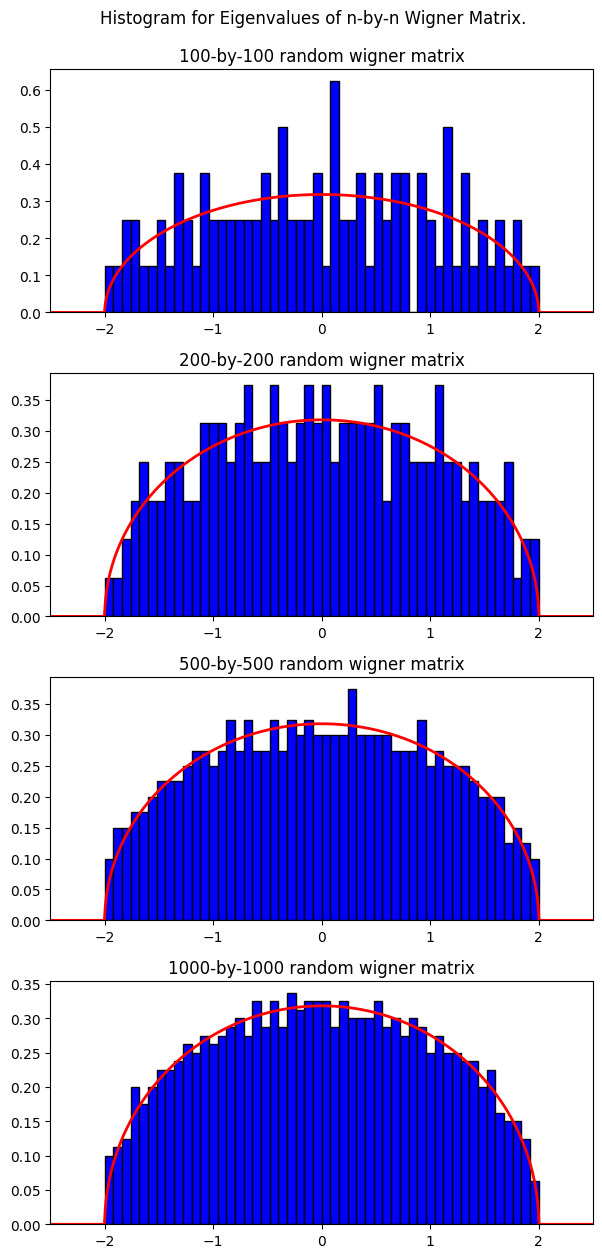

In [19]:
x = np.linspace(-3, 3, 1000)
y = list(map(lambda xi: wigner_density(xi), x))

arr = [100, 200, 500, 1000]
wigner_matrix = list(map(lambda n: generate_wigner(n), arr))
wigner_eigenvalues = list(map(lambda Z: get_spectrum(Z), wigner_matrix))
scaled_wigner_eigenvalue = list(map(lambda x: scale_wigner_eigenvalue(x, 2, -2), wigner_eigenvalues))

wigner_plot(arr, scaled_wigner_eigenvalue, x , y)

**At least based on looking at the plots, how big does `n` have to be before the semicircular law appears to be a good fit? In practice, we would answer this question more rigorously with, for example, a Kolmogorov-Smirnov test, which you can find in the `scipy.stats` module, but that is entirely optional.**

**Note: this experiment involves some matrix eigenvalue computations, which are comparatively expensive. If you set n larger than about 5000, be prepared to wait a few minutes for your answer, especially if you are running on an older machine or on a VM.**

Looking at the above example, a 1000-by-1000 Wigner Matrix eigenvalues do seem to fit very well with the semicircular law. That said, a 5000-by-5000 Wigner Matrix smoothens out the edges and gives us a very good approximation of the semicircular law. However, given the time it takes to run it, I believe a 1000-by-1000 is sufficient for most purposes.

In [24]:
n = 5000
wigner_eigenvalue = get_spectrum( generate_wigner(n) )
scaled_wigner_eigenvalue = scale_wigner_eigenvalue(wigner_eigenvalue, 2, -2)

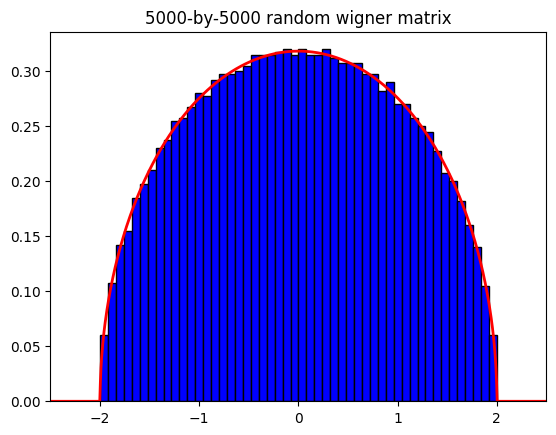

In [25]:
plt.hist(scaled_wigner_eigenvalue, 
         density = True,
         bins = 50,
         color = 'blue',
         edgecolor = 'black',
         alpha = 1)
plt.plot(x, y, color = 'red', linewidth = 2)        
plt.xlim([-2.5, 2.5])
plt.title(f'{n}-by-{n} random wigner matrix')

plt.show()

## 2.) Plotting a Mixture of Normals (3 points, spent $\approx$ )

**The whole reason that we use plotting software is to visualize the data that we are working with, so let’s do that. The zip file located at https://pages.stat.wisc.edu/~kdlevin/teaching/Spring2024/STAT606/hw/hw6_files.zip contains two files, storing data from a simulation experiment in my own research. The file points.dlm is a tab-delimited file (.dlm stands for “delimited”). Such a format is common when writing reasonably small files, and is useful if you expect to use a data set across different programs or platforms.**

**See the documentation for the command numpy.loadtxt to see how to read this file. The file labels.npy is a numpy binary file, representing a numpy object. The .npy file format is specific to numpy. Many languages (e.g., R and MATLAB) have their own such language-specific file formats for saving variables, workspaces, etc. These formats tend to be more space-efficient, typically at the cost of program-dependence. It is best to avoid such files if you expect to deal with the same data set in several different environments (e.g., you run experiments in MATLAB and do your statistical analysis in R). .npy files are opened using numpy.load.**

In [1]:
import os
path_dir = 'ssudhir2_hw6/hw6_files'
os.chdir(path_dir)

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'ssudhir2_hw6/hw6_files'

In [3]:
os.getcwd()

'C:\\Users\\shriv\\AppData\\Local\\Programs\\Microsoft VS Code'

In [33]:
os.getcwd()

'C:\\Users\\shriv\\AppData\\Local\\Programs\\Microsoft VS Code'